## 0. Environment Setup

In [1]:
import os
import warnings
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import yfinance as yf
from dotenv import load_dotenv
from scipy import stats

warnings.filterwarnings("ignore")
load_dotenv()

# ── Plotting style ───────────────────────────────────────────────────────────
plt.style.use("dark_background")
COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "neutral": "#B0BEC5",
    "accent": "#ab47bc",
}

# ── V3 asset universe (GNN nodes, §3-C) ──────────────────────────────────────
UNIVERSE = [
    "SPY",
    "AAPL",
    "MSFT",
    "NVDA",
    "AMD",
    "SMCI",
    "GLD",
    "USO",
    "^VIX",
    "TLT",
    "QQQ",
    "GOOGL",
]

# ── Time window for exploration ──────────────────────────────────────────────
END = datetime.today()
START = END - timedelta(days=365 * 3)  # 3 years of daily data

print(f"Universe : {UNIVERSE}")
print(f"Window   : {START.date()} ⟶ {END.date()}")

Universe : ['SPY', 'AAPL', 'MSFT', 'NVDA', 'AMD', 'SMCI', 'GLD', 'USO', '^VIX', 'TLT', 'QQQ', 'GOOGL']
Window   : 2023-03-11 ⟶ 2026-03-10


## 1. Price Data ─ OHLCV Quality Audit

In [2]:
# Download daily OHLCV for the full universe
raw_prices: dict[str, pd.DataFrame] = {}

for ticker in UNIVERSE:
    try:
        df = yf.download(
            ticker, start=START, end=END, progress=False, auto_adjust=True
        )
        raw_prices[ticker] = df
        print(
            f"  {ticker:<6} → {len(df):>4} rows | "
            f"NaN close: {df['Close'].isna().sum()}"
        )
    except Exception as exc:
        print(f"  {ticker:<6} → ERROR: {exc}")

  SPY    →  751 rows | NaN close: Ticker
SPY    0
dtype: int64
  AAPL   →  751 rows | NaN close: Ticker
AAPL    0
dtype: int64
  MSFT   →  751 rows | NaN close: Ticker
MSFT    0
dtype: int64
  NVDA   →  751 rows | NaN close: Ticker
NVDA    0
dtype: int64
  AMD    →  751 rows | NaN close: Ticker
AMD    0
dtype: int64
  SMCI   →  751 rows | NaN close: Ticker
SMCI    0
dtype: int64
  GLD    →  751 rows | NaN close: Ticker
GLD    0
dtype: int64
  USO    →  751 rows | NaN close: Ticker
USO    0
dtype: int64
  ^VIX   →  751 rows | NaN close: Ticker
^VIX    0
dtype: int64
  TLT    →  751 rows | NaN close: Ticker
TLT    0
dtype: int64
  QQQ    →  751 rows | NaN close: Ticker
QQQ    0
dtype: int64
  GOOGL  →  751 rows | NaN close: Ticker
GOOGL    0
dtype: int64


In [3]:
# Assemble close-price matrix ─ the GNN correlation backbone


def _get_close_series(df: pd.DataFrame, ticker: str) -> pd.Series:
    if not isinstance(df, pd.DataFrame) or df.empty:
        return pd.Series(dtype="float64", name=ticker)

    # yfinance puede devolver columnas simples o MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        if ("Close", ticker) in df.columns:
            s = df[("Close", ticker)]
        elif "Close" in df.columns.get_level_values(0):
            s = df.xs("Close", axis=1, level=0).squeeze()
        else:
            s = pd.Series(index=df.index, dtype="float64")
    else:
        col = (
            "Close"
            if "Close" in df.columns
            else ("Adj Close" if "Adj Close" in df.columns else None)
        )
        s = df[col] if col else pd.Series(index=df.index, dtype="float64")

    return pd.to_numeric(s, errors="coerce").rename(ticker)


close_series = [_get_close_series(df, t) for t, df in raw_prices.items()]
close_matrix = pd.concat(close_series, axis=1).sort_index().dropna(how="all")

print(f"Close matrix shape : {close_matrix.shape}")
print(f"Missing values     : {close_matrix.isna().sum().sum()}")
close_matrix.tail(5)

Close matrix shape : (751, 12)
Missing values     : 0


,SPY,AAPL,MSFT,NVDA,AMD,SMCI,GLD,USO,^VIX,TLT,QQQ,GOOGL
Date,,,,,,,,,,,,
2026-03-04,685.130005,262.519989,405.200012,183.039993,202.070007,32.650002,471.799988,91.559998,21.15,89.150002,610.750000,302.916779
2026-03-05,681.309998,260.290009,410.679993,183.339996,199.449997,32.240002,466.130005,96.309998,23.75,88.790001,608.909973,300.668335
2026-03-06,672.380005,257.459991,408.959991,177.820007,192.429993,31.309999,473.510010,108.769997,29.49,88.459999,599.750000,298.309998
2026-03-09,678.270020,259.880005,409.410004,182.649994,202.679993,31.980000,472.529999,104.330002,25.50,89.230003,607.760010,306.359985
2026-03-10,677.191284,260.709991,404.644989,184.065002,203.339996,31.969999,477.230011,105.669998,24.50,88.375000,607.575012,306.769989


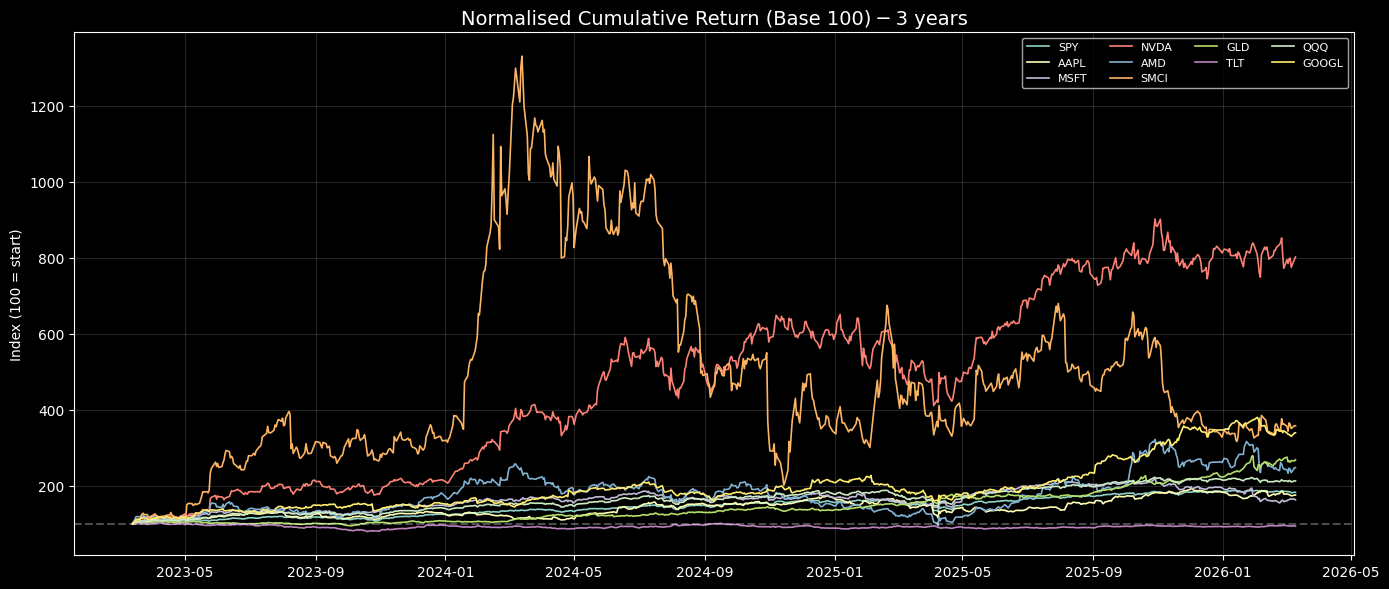

Saved ⟶ 01_cumulaitve_returns.png


In [4]:
# Normalised cumulative return plot (base 100) ─ visual sanity check
cum_returns = (close_matrix / close_matrix.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
for col in cum_returns.columns:
    if col not in ["^VIX", "USO"]:  # exclude non-equity for clarity
        ax.plot(cum_returns.index, cum_returns[col], linewidth=1.2, label=col)

ax.axhline(100, color="white", linestyle="--", alpha=0.3)
ax.set_title(
    "Normalised Cumulative Return (Base 100) ─ 3 years",
    fontsize=14,
    color="white",
)
ax.set_ylabel("Index (100 = start)")
ax.legend(ncol=4, fontsize=8)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("01/01_cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ⟶ 01_cumulaitve_returns.png")

## 2. Intra-day Data ─ Frequency Analysis for TFT Input

In [5]:
# The TFT Temporal Encoder consumes 1m, 5m, 1h candles (§3-A).
# Download 7 days of intra-day data for AAPL at multiple resolutions
INTRADAY_TICKER = "AAPL"
INTRADAY_PERIODS = {"1m": "7d", "5m": "60d", "1h": "730d"}

intraday: dict[str, pd.DataFrame] = {}
for interval, period in INTRADAY_PERIODS.items():
    df = yf.download(
        INTRADAY_TICKER,
        period=period,
        interval=interval,
        progress=False,
        auto_adjust=True,
    )
    intraday[interval] = df
    expected_bars = len(df)
    print(
        f"  {interval:<4} → {expected_bars:>6} bars | "
        f"NaN vol: {df['Volume'].isna().sum()}"
    )

  1m   →   2706 bars | NaN vol: Ticker
AAPL    0
dtype: int64
  5m   →   4640 bars | NaN vol: Ticker
AAPL    0
dtype: int64
  1h   →   5078 bars | NaN vol: Ticker
AAPL    0
dtype: int64


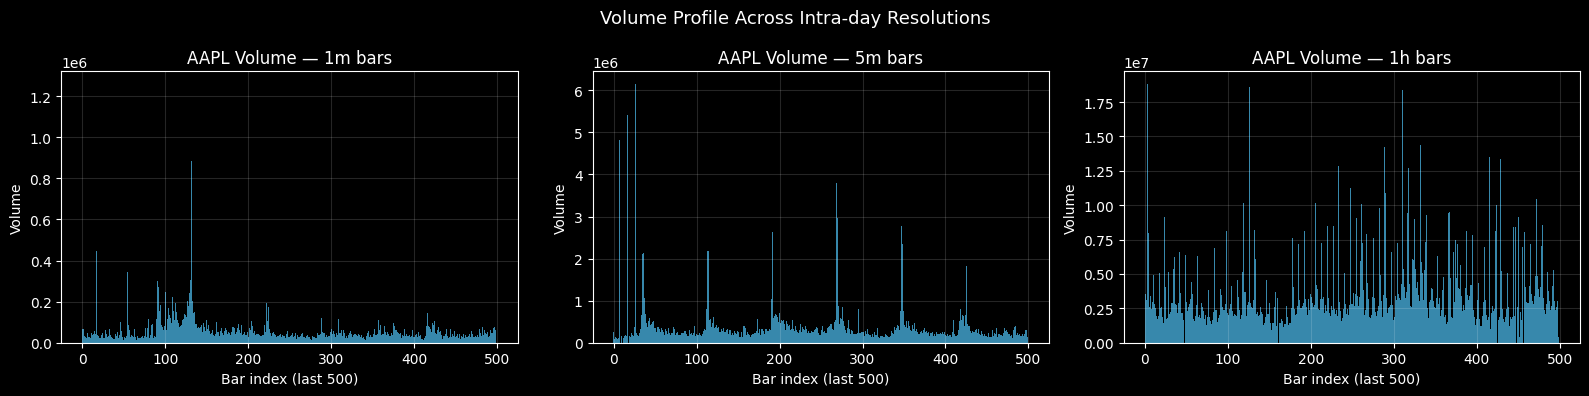

In [6]:
# Volume profile across intra-day intervals (important for VSN in TFT)


def _get_volume_series(df: pd.DataFrame, ticker: str) -> pd.Series:
    if not isinstance(df, pd.DataFrame) or df.empty:
        return pd.Series(dtype="float64")

    if isinstance(df.columns, pd.MultiIndex):
        if ("Volume", ticker) in df.columns:
            s = df[("Volume", ticker)]
        elif "Volume" in df.columns.get_level_values(0):
            vol_block = df.xs("Volume", axis=1, level=0)
            s = (
                vol_block.iloc[:, 0]
                if isinstance(vol_block, pd.DataFrame)
                else vol_block
            )
        else:
            s = pd.Series(index=df.index, dtype="float64")
    else:
        s = (
            df["Volume"]
            if "Volume" in df.columns
            else pd.Series(index=df.index, dtype="float64")
        )

    return pd.to_numeric(s, errors="coerce")


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (interval, df) in zip(axes, intraday.items(), strict=False):
    vol = _get_volume_series(df, INTRADAY_TICKER).tail(500).dropna()
    x = np.arange(len(vol))
    ax.bar(x, vol.values, color=COLORS["primary"], alpha=0.7, width=1.0)
    ax.set_title(f"{INTRADAY_TICKER} Volume — {interval} bars")
    ax.set_xlabel("Bar index (last 500)")
    ax.set_ylabel("Volume")
    ax.grid(alpha=0.15)

plt.suptitle("Volume Profile Across Intra-day Resolutions", fontsize=13)
plt.tight_layout()
plt.savefig("01/01_volume_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Return Distribution ─ Fat Tails & Non-Normality

In [7]:
# RL reward functions are sensitive to return distributions.
# We check kurtosis and skewness ─ heavy tails need robust normalisation.
daily_returns = close_matrix.pct_change().dropna()

print(
    f"{'Ticker':<8} {'Mean':>8} {'Std':>8} "
    f"{'Skew':>8} {'Kurt':>8} {'JB p-val':>10}"
)
print("-" * 55)
for col in daily_returns.columns:
    s = daily_returns[col].dropna()
    jb_stat, jb_p = stats.jarque_bera(s)
    print(
        f"{col:<8} {s.mean():>8.4f} {s.std():>8.4f} "
        f"{s.skew():>8.3f} {s.kurtosis():>8.3f} {jb_p:>10.4f}"
    )

Ticker       Mean      Std     Skew     Kurt   JB p-val
-------------------------------------------------------
SPY        0.0008   0.0095    0.956   22.438     0.0000
AAPL       0.0009   0.0162    0.806   13.355     0.0000
MSFT       0.0008   0.0149   -0.009    7.235     0.0000
NVDA       0.0032   0.0307    0.788    8.827     0.0000
AMD        0.0018   0.0335    0.781    7.641     0.0000
SMCI       0.0035   0.0603    0.640    6.730     0.0000
GLD        0.0014   0.0119   -1.005   10.216     0.0000
USO        0.0008   0.0196    0.226    3.161     0.0000
^VIX       0.0030   0.0827    2.266   16.478     0.0000
TLT       -0.0000   0.0091   -0.118    0.510     0.0086
QQQ        0.0011   0.0123    0.632   12.800     0.0000
GOOGL      0.0018   0.0184    0.143    4.544     0.0000


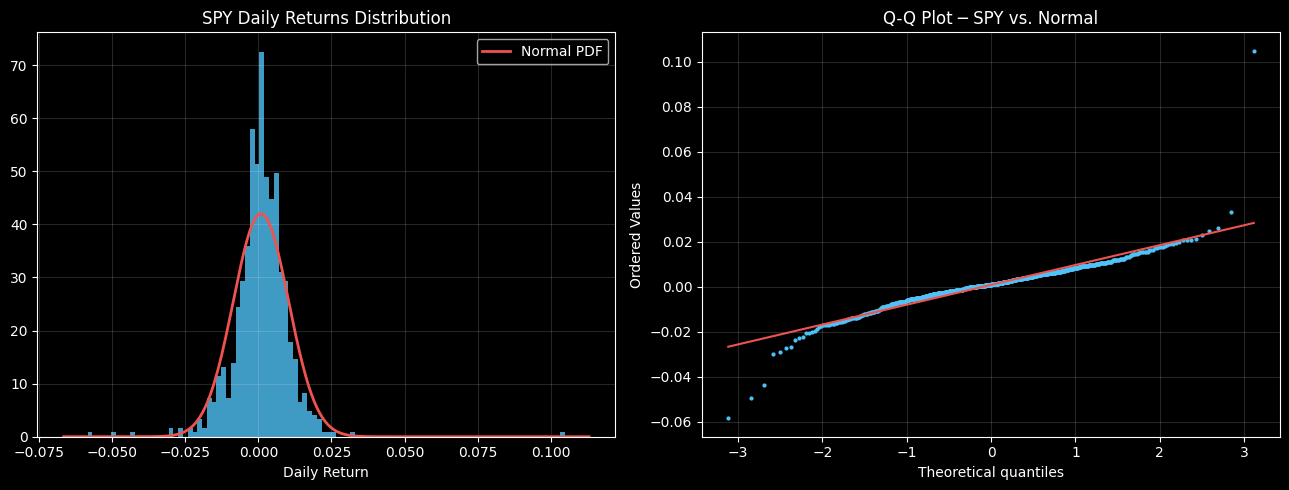

In [8]:
# Return distribution histogram for SPY ─ normality baseline
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

r = daily_returns["SPY"].dropna()
axes[0].hist(r, bins=100, color=COLORS["primary"], alpha=0.8, density=True)
xmin, xmax = axes[0].get_xlim()
xs = np.linspace(xmin, xmax, 300)
axes[0].plot(
    xs,
    stats.norm.pdf(xs, r.mean(), r.std()),
    color=COLORS["danger"],
    linewidth=2,
    label="Normal PDF",
)
axes[0].set_title("SPY Daily Returns Distribution")
axes[0].set_xlabel("Daily Return")
axes[0].legend()
axes[0].grid(alpha=0.15)

stats.probplot(r, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot ─ SPY vs. Normal")
axes[1].get_lines()[0].set(color=COLORS["primary"], markersize=2)
axes[1].get_lines()[1].set(color=COLORS["danger"])
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.savefig("01/01_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Volatility Regime Detection ─ Input to Spartan Curriculum

In [9]:
# The Spartan curriculum (§7) warps volatility 2x-5x during Phase B.
# We first characterise the real-world volatility regimes to calibrate
# the warp.
spy_returns = daily_returns["SPY"].dropna()

# Rolling 21-day realised volatility (annualised)
rolling_vol = spy_returns.rolling(21).std() * np.sqrt(252)


# Simple regime labels based on VIX-like thresholds
def label_regime(vol: float) -> str:
    if vol < 0.12:
        return "Low"
    elif vol < 0.20:
        return "Normal"
    elif vol < 0.35:
        return "Elevated"
    else:
        return "Crisis"


regime_labels = rolling_vol.dropna().apply(label_regime)
regime_counts = regime_labels.value_counts()
print("Volatility regime distribution (daily):")
print(regime_counts.to_string())

Volatility regime distribution (daily):
SPY
Low         383
Normal      292
Elevated     34
Crisis       21


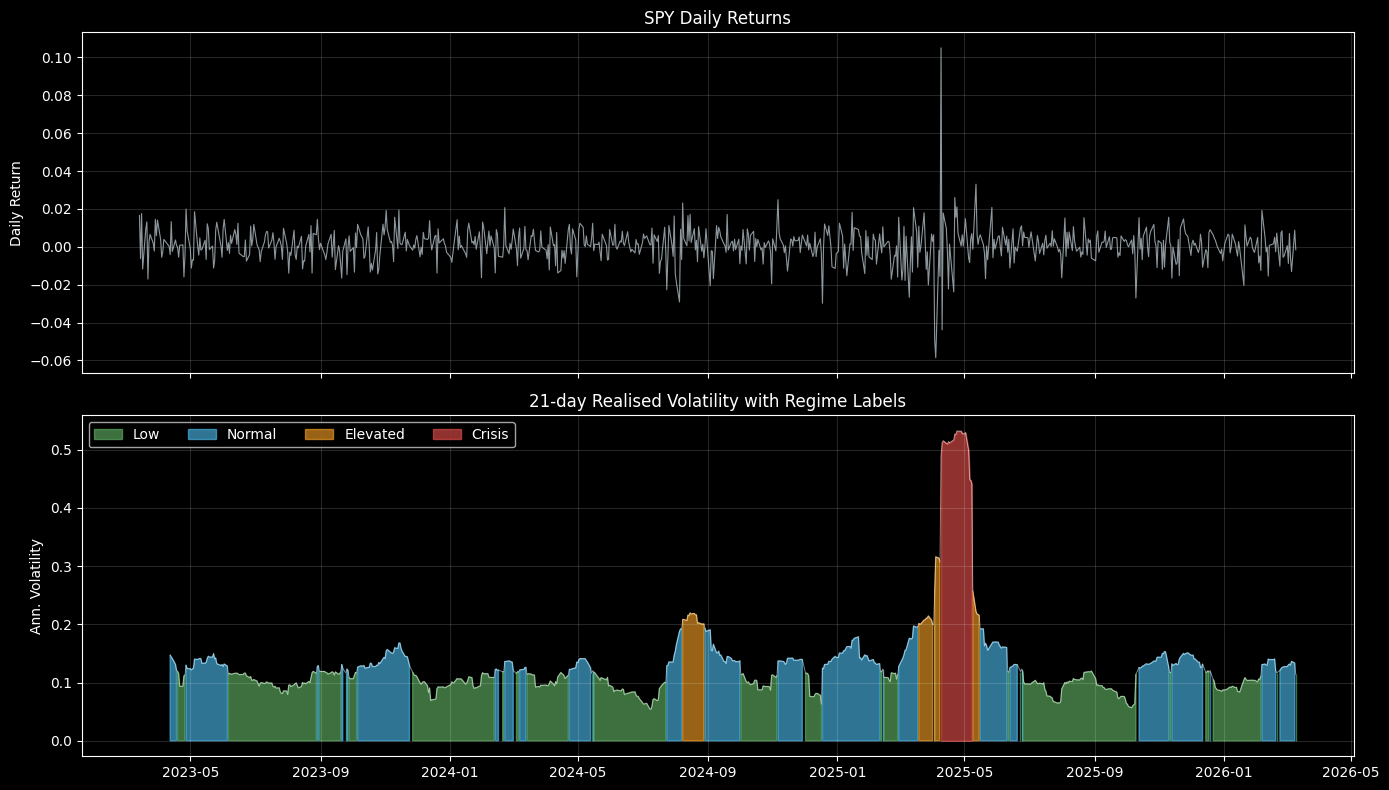

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(
    spy_returns.index,
    spy_returns,
    color=COLORS["neutral"],
    linewidth=0.8,
    alpha=0.8,
)
axes[0].set_title("SPY Daily Returns", fontsize=12)
axes[0].set_ylabel("Daily Return")
axes[0].grid(alpha=0.15)

colors_map = {
    "Low": COLORS["success"],
    "Normal": COLORS["primary"],
    "Elevated": COLORS["warning"],
    "Crisis": COLORS["danger"],
}
for label, color in colors_map.items():
    mask = regime_labels == label
    axes[1].fill_between(
        rolling_vol.index,
        rolling_vol,
        where=mask.reindex(rolling_vol.index, fill_value=False),
        alpha=0.6,
        color=color,
        label=label,
    )
axes[1].plot(
    rolling_vol.index, rolling_vol, color="white", linewidth=0.7, alpha=0.5
)
axes[1].set_title("21-day Realised Volatility with Regime Labels", fontsize=12)
axes[1].set_ylabel("Ann. Volatility")
axes[1].legend(ncol=4)
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.savefig("01/01_volatility_regimes.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Correlation Structure ─ GNN Edge Blueprint

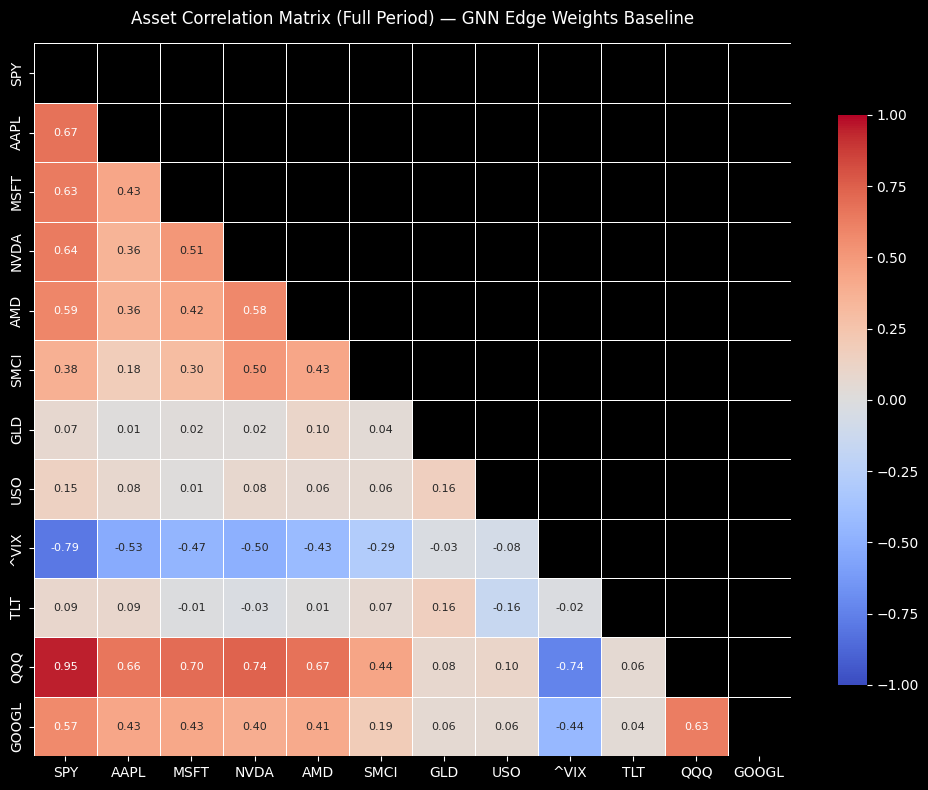

High-correlation pairs (|r| > 0.80):
  SPY      ↔ QQQ      : 0.949


In [11]:
# The GNN Structural Encoder uses a rolling 30-day correlation matrix as
# dynamic edge weights (§3-C). We visualize the static (full-period) matrix
# as a baseline for graph construction in notebook 07.

corr_matrix = daily_returns[
    [t for t in UNIVERSE if t in daily_returns.columns]
].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8},
)
ax.set_title(
    "Asset Correlation Matrix (Full Period) — GNN Edge Weights Baseline",
    fontsize=12,
    pad=14,
)
plt.tight_layout()
plt.savefig("01/01_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Print high-correlation pairs (strong GNN edges)
print("High-correlation pairs (|r| > 0.80):")
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.80:
            print(
                f"  {corr_matrix.index[i]:<8} ↔ {corr_matrix.columns[j]:<8} : "
                f"{r:.3f}"
            )

## 6. Macro / FRED Data Availability

In [12]:
# FRED macro indicators provide Static Covariates for the TFT encoder (§3-A).
# Check series availability and gaps before feature engineering.
try:
    import pandas_datareader.data as pdr

    FRED_SERIES = {
        "DFF": "Fed Funds Rate",
        "T10Y2Y": "Yield Curve (10Y-2Y)",
        "DCOILWTICO": "WTI Crude Oil",
        "VIXCLS": "VIX (CBOE)",
        "UNRATE": "Unemployment Rate",
    }

    fred_data: dict[str, pd.Series] = {}
    for code, name in FRED_SERIES.items():
        try:
            s = pdr.DataReader(code, "fred", START, END)
            fred_data[code] = s.squeeze()
            print(
                f"  {code:<12} ({name:<20}) ⟶ {len(s):>4} obs | "
                f"NaN: {s.isna().sum().iloc[0]}"
            )
        except Exception as e:
            print(f"  {code:<12} ⟶ UNAVAILABLE ({e})")

except ImportError:
    print("pandas_datareader not installed. Skipping FRED download.")
    print("Install width: pip install pandas-datareader")

  DFF          (Fed Funds Rate      ) ⟶ 1091 obs | NaN: 0
  T10Y2Y       (Yield Curve (10Y-2Y)) ⟶  781 obs | NaN: 34
  DCOILWTICO   (WTI Crude Oil       ) ⟶  776 obs | NaN: 37
  VIXCLS       (VIX (CBOE)          ) ⟶  781 obs | NaN: 9
  UNRATE       (Unemployment Rate   ) ⟶   35 obs | NaN: 1


## 7. News Data Quality Check

In [13]:
# NewsAPI feeds the Semantic Encoder (DistilRoBERTa, §3-B).
# We inspect headline availability per ticker — too few headlines per day
# means sparse semantic embeddings, which the Fusion Attention Block must
# handle.

NEWS_API_KEY = os.getenv("NEWS_API_KEY", "")

if NEWS_API_KEY:
    news_stats: list[dict] = []
    from_date = (END - timedelta(days=30)).strftime("%Y-%m-%d")
    to_date = END.strftime("%Y-%m-%d")

    for ticker in ["AAPL", "MSFT", "NVDA", "SPY"]:
        try:
            resp = requests.get(
                "https://newsapi.org/v2/everything?",
                params={
                    "q": ticker,
                    "from": from_date,
                    "sortBy": "publishedAt",
                    "pageSize": 100,
                    "apiKey": NEWS_API_KEY,
                },
                timeout=30,
            )
            resp.raise_for_status()
            payload = resp.json()

            news_stats.append(
                {
                    "ticker": ticker,
                    "total_results": payload.get("totalResults", 0),
                    "returned": len(payload.get("articles", [])),
                }
            )
        except Exception as exc:
            print(f"  {ticker} → NewsAPI error: {exc}")

    if news_stats:
        df_news = pd.DataFrame(news_stats)
        print("\nNewsAPI headline availability (last 30 days):")
        print(df_news.to_string(index=False))
else:
    print("NEWS_API_KEY not set in .env — skipping live news check.")
    print("Set NEWS_API_KEY=<your_key> to enable semantic data audit.")

  AAPL → NewsAPI error: 426 Client Error: Upgrade Required for url: https://newsapi.org/v2/everything?q=AAPL&from=2026-02-08&sortBy=publishedAt&pageSize=100&apiKey=a8d2fac746fe4d449673e2fedd00eaba
  MSFT → NewsAPI error: 426 Client Error: Upgrade Required for url: https://newsapi.org/v2/everything?q=MSFT&from=2026-02-08&sortBy=publishedAt&pageSize=100&apiKey=a8d2fac746fe4d449673e2fedd00eaba
  NVDA → NewsAPI error: 426 Client Error: Upgrade Required for url: https://newsapi.org/v2/everything?q=NVDA&from=2026-02-08&sortBy=publishedAt&pageSize=100&apiKey=a8d2fac746fe4d449673e2fedd00eaba
  SPY → NewsAPI error: 426 Client Error: Upgrade Required for url: https://newsapi.org/v2/everything?q=SPY&from=2026-02-08&sortBy=publishedAt&pageSize=100&apiKey=a8d2fac746fe4d449673e2fedd00eaba


## 8. Summary — Data Readiness Scorecard

In [14]:
# Produce a readiness checklist before proceeding to feature engineering.
checks = {
    "OHLCV daily (≥3 years)": len(close_matrix) >= 756,
    "OHLCV intraday 1m (≥5 days)": len(intraday.get("1m", [])) >= 1950,
    "OHLCV intraday 1h (≥1 year)": len(intraday.get("1h", [])) >= 1560,
    "Close matrix NaN < 5%": (close_matrix.isna().mean().mean() < 0.05),
    "Correlation matrix computed": corr_matrix is not None,
    "Return skew (SPY) in [-1, 1]": abs(daily_returns["SPY"].skew()) < 1.0,
    "At least 2 volatility regimes seen": regime_counts.shape[0] >= 2,
    "Universe ≥ 10 assets": len(UNIVERSE) >= 10,
}

print("=" * 55)
print("  DATA READINESS SCORECARD — Lumina V3 Chimera")
print("=" * 55)
all_pass = True
for check, passed in checks.items():
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"    {status}  {check}")
    if not passed:
        all_pass = False

print("=" * 55)
print(
    f"  Overall: {'READY TO PROCEED ✅' if all_pass else 'FIX ISSUES ABOVE ❌'}"
)
print("=" * 55)

  DATA READINESS SCORECARD — Lumina V3 Chimera
    ❌ FAIL  OHLCV daily (≥3 years)
    ✅ PASS  OHLCV intraday 1m (≥5 days)
    ✅ PASS  OHLCV intraday 1h (≥1 year)
    ✅ PASS  Close matrix NaN < 5%
    ✅ PASS  Correlation matrix computed
    ✅ PASS  Return skew (SPY) in [-1, 1]
    ✅ PASS  At least 2 volatility regimes seen
    ✅ PASS  Universe ≥ 10 assets
  Overall: FIX ISSUES ABOVE ❌
